# Project #4 – Natural Disaster Risk Sensitivity Analysis  



In [153]:



import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

print("Working directory:", BASE_DIR)
print("Output directory:", OUTPUT_DIR)

Working directory: /Users/carterjanssen/Spring 2026/Project 4
Output directory: /Users/carterjanssen/Spring 2026/Project 4/outputs


## Define local file paths


In [155]:
FILE_MAP = {"nri": { "Iowa": "state_tracs_Iowa.csv",
        "Nebraska": "NRI_Table_CensusTracts_Nebraska.csv",
        "California": "state_tracs_California.csv",},
    "svi": {"Iowa": "Iowa.csv",
        "Nebraska": "Nebraska.csv",
        "California": "California.csv",},
    "dictionary": "NRIDataDictionary.csv",}

for group, value in FILE_MAP.items():
    print(f"\n{group.upper()}")
    print(value)


NRI
{'Iowa': 'state_tracs_Iowa.csv', 'Nebraska': 'NRI_Table_CensusTracts_Nebraska.csv', 'California': 'state_tracs_California.csv'}

SVI
{'Iowa': 'Iowa.csv', 'Nebraska': 'Nebraska.csv', 'California': 'California.csv'}

DICTIONARY
NRIDataDictionary.csv


##  Helper functions

In [157]:

def standardize_fips(series, width=11):
    return (
        pd.to_numeric(series, errors="coerce")
        .fillna(0)
        .astype("int64")
        .astype(str)
        .str.zfill(width)
    )

def replace_nri_nulls(df):
   
    return df.replace({-9999: np.nan, -9998: np.nan, -9997: np.nan})

def replace_svi_nulls(df):
   
    return df.replace({-999: np.nan, -999.0: np.nan, -99: np.nan, -99.0: np.nan})

def percentile_0_100(series):
    valid = series.notna()
    out = pd.Series(np.nan, index=series.index, dtype=float)
    if valid.sum() > 0:
        out.loc[valid] = series.loc[valid].rank(method="average", pct=True) * 100
    return out

def five_class_rating(score):
    bins = [-np.inf, 20, 40, 60, 80, np.inf]
    labels = ["Very Low", "Relatively Low", "Relatively Moderate", "Relatively High", "Very High"]
    return pd.cut(score, bins=bins, labels=labels, include_lowest=True, right=True)

def load_nri(state_name, filename):
    df = pd.read_csv(find_file(filename), low_memory=False)
    df = replace_nri_nulls(df).copy()
    df["STATE_SOURCE"] = state_name
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])
    df["TRACTFIPS_STR"] = standardize_fips(df["TRACTFIPS"])
    return df

def load_svi(state_name, filename):
    df = pd.read_csv(find_file(filename), low_memory=False)
    df = replace_svi_nulls(df).copy()
    df["STATE_SOURCE"] = state_name
    df["FIPS_STR"] = standardize_fips(df["FIPS"])
    return df

## Load the three NRI tract datasets

In [159]:
nri_frames = []
for state, filename in FILE_MAP["nri"].items():
    temp = load_nri(state, filename)
    nri_frames.append(temp)

nri = pd.concat(nri_frames, ignore_index=True)
print("NRI combined shape:", nri.shape)
nri[["STATE", "COUNTY", "TRACTFIPS", "RISK_SCORE", "EAL_SCORE", "SOVI_SCORE", "RESL_SCORE"]].head(5)

NRI combined shape: (10555, 495)


,STATE,COUNTY,TRACTFIPS,RISK_SCORE,EAL_SCORE,SOVI_SCORE,RESL_SCORE
0,Iowa,Adair,19001960100,98.463606,97.287268,82.215246,52.506812
1,Iowa,Adair,19001960200,89.374859,93.159452,28.384173,52.506812
2,Iowa,Adair,19001960300,94.886614,93.361439,69.307588,52.506812
3,Iowa,Adams,19003950100,95.757078,95.741832,55.065450,44.966236
4,Iowa,Adams,19003950200,87.402043,86.577260,56.420068,44.966236


##  Load the three SVI datasets

In [161]:
svi_frames = []
for state, filename in FILE_MAP["svi"].items():
    temp = load_svi(state, filename)
    svi_frames.append(temp)

svi = pd.concat(svi_frames, ignore_index=True)
print("SVI combined shape:", svi.shape)
svi[["STATE", "COUNTY", "FIPS", "RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4", "RPL_THEMES"]].head()

SVI combined shape: (10558, 160)


,STATE,COUNTY,FIPS,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,RPL_THEMES
0,Iowa,Adair County,19001960100,0.6386,0.6554,0.3147,0.5814,0.6352
1,Iowa,Adair County,19001960200,0.2761,0.1134,0.1377,0.0426,0.0584
2,Iowa,Adair County,19001960300,0.5275,0.4119,0.2240,0.7531,0.5499
3,Iowa,Adams County,19003950100,0.5522,0.3591,0.1982,0.2783,0.3558
4,Iowa,Adams County,19003950200,0.5769,0.8025,0.2632,0.7093,0.6768


## Load and inspect the NRI data dictionary



In [163]:
data_dict = pd.read_csv(find_file(FILE_MAP["dictionary"]), low_memory=False)
print("Data dictionary shape:", data_dict.shape)
data_dict.head(10)

Data dictionary shape: (479, 9)


,Sort,Field Name,Field Alias,Type,Length,Relevant Layer,Metric Type,Version,Version Date
0,1,OBJECTID,OBJECTID,Integer,4.0,NaN,NaN,1.19.0,March 2023
1,2,Shape,Shape,Geometry,NaN,NaN,NaN,1.19.0,March 2023
2,3,Shape_Length,Shape_Length,Double,8.0,NaN,NaN,1.19.0,March 2023
3,4,Shape_Area,Shape_Area,Double,8.0,NaN,NaN,1.19.0,March 2023
4,5,STATE,State Name,String,250.0,All,NaN,1.19.0,March 2023
5,6,STATEABBRV,State Name Abbreviation,String,20.0,All,NaN,1.19.0,March 2023
6,7,STATEFIPS,State FIPS Code,String,20.0,All,NaN,1.19.0,March 2023
7,8,COUNTY,County Name,String,250.0,All,NaN,1.19.0,March 2023
8,9,COUNTYTYPE,County Type,String,250.0,All,NaN,1.19.0,March 2023
9,10,COUNTYFIPS,County FIPS Code,String,20.0,All,NaN,1.19.0,March 2023


## Variables used in this analysis

In [165]:
key_fields = [
    "TRACTFIPS", "POPULATION", "BUILDVALUE",
    "RISK_VALUE", "RISK_SCORE", "RISK_RATNG", "RISK_SPCTL",
    "EAL_VALT", "EAL_SCORE", "EAL_RATNG", "EAL_SPCTL",
    "SOVI_SCORE", "SOVI_RATNG", "SOVI_SPCTL",
    "RESL_SCORE", "RESL_RATNG", "RESL_SPCTL", "RESL_VALUE", "CRF_VALUE"
]

dictionary_subset = data_dict[data_dict["Field Name"].isin(key_fields)].copy()
dictionary_subset = dictionary_subset.sort_values("Field Name")
dictionary_subset.to_csv(TABLE_DIR / "nri_dictionary_subset.csv", index=False)
dictionary_subset

,Sort,Field Name,Field Alias,Type,Length,Relevant Layer,Metric Type,Version,Version Date
15,16,BUILDVALUE,Building Value ($),Double,8.0,All,NaN,1.19.0,March 2023
42,43,CRF_VALUE,Community Risk Factor - Value,Double,8.0,Community Risk Factor,Value,1.19.0,March 2023
23,24,EAL_RATNG,Expected Annual Loss - Rating - Composite,String,50.0,Expected Annual Loss,Rating,1.19.0,March 2023
22,23,EAL_SCORE,Expected Annual Loss - Score - Composite,Double,8.0,Expected Annual Loss,Score,1.19.0,March 2023
24,25,EAL_SPCTL,Expected Annual Loss - State Percentile - Comp...,Double,8.0,Expected Annual Loss,State Percentile,1.19.0,March 2023
25,26,EAL_VALT,Expected Annual Loss - Total - Composite,Double,8.0,Expected Annual Loss,Value,1.19.0,March 2023
14,15,POPULATION,Population (2020),Integer,4.0,All,NaN,1.19.0,March 2023
39,40,RESL_RATNG,Community Resilience - Rating,String,50.0,Community Resilience,Rating,1.19.0,March 2023
38,39,RESL_SCORE,Community Resilience - Score,Double,8.0,Community Resilience,Score,1.19.0,March 2023
40,41,RESL_SPCTL,Community Resilience - State Percentile,Double,8.0,Community Resilience,State Percentile,1.19.0,March 2023


##  Select and rename the main project variables


In [167]:
nri_keep = [
    "STATE", "COUNTY", "TRACT", "TRACTFIPS", "TRACTFIPS_STR", "POPULATION", "BUILDVALUE", "AREA",
    "RISK_VALUE", "RISK_SCORE", "RISK_RATNG", "RISK_SPCTL",
    "EAL_VALT", "EAL_VALB", "EAL_VALP", "EAL_VALPE", "EAL_SCORE", "EAL_RATNG", "EAL_SPCTL",
    "SOVI_SCORE", "SOVI_RATNG", "SOVI_SPCTL",
    "RESL_SCORE", "RESL_RATNG", "RESL_SPCTL", "RESL_VALUE", "CRF_VALUE"
]

svi_keep = [
    "STATE", "COUNTY", "FIPS", "FIPS_STR", "LOCATION", "AREA_SQMI", "E_TOTPOP", "E_HU", "E_HH",
    "RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4", "RPL_THEMES",
    "EP_POV150", "EP_UNEMP", "EP_HBURD", "EP_NOHSDP", "EP_UNINSUR",
    "EP_AGE65", "EP_AGE17", "EP_DISABL", "EP_SNGPNT", "EP_LIMENG", "EP_MINRTY", "EP_MUNIT", "EP_MOBILE",
    "EP_CROWD", "EP_NOVEH", "EP_GROUPQ"
]

nri_main = nri[nri_keep].copy()
svi_main = svi[svi_keep].copy()

print(nri_main.shape, svi_main.shape)

(10555, 27) (10558, 30)


##  Join the NRI and SVI data at the Census Tract level

In [169]:
merged = nri_main.merge(
    svi_main,
    left_on="TRACTFIPS_STR",
    right_on="FIPS_STR",
    how="left",
    suffixes=("_NRI", "_SVI")
)

print("Merged shape:", merged.shape)
print("Matched SVI rows:", merged["RPL_THEMES"].notna().sum(), "of", len(merged))
merged[["STATE_NRI", "COUNTY_NRI", "TRACTFIPS_STR", "RISK_SCORE", "RPL_THEMES"]].head()

Merged shape: (10555, 57)
Matched SVI rows: 10484 of 10555


,STATE_NRI,COUNTY_NRI,TRACTFIPS_STR,RISK_SCORE,RPL_THEMES
0,Iowa,Adair,19001960100,98.463606,0.6352
1,Iowa,Adair,19001960200,89.374859,0.0584
2,Iowa,Adair,19001960300,94.886614,0.5499
3,Iowa,Adams,19003950100,95.757078,0.3558
4,Iowa,Adams,19003950200,87.402043,0.6768


##  Missing-value handling and data cleaning summary


In [171]:

merged["STATE"] = merged["STATE_NRI"].fillna(merged["STATE_SVI"])
merged["COUNTY"] = merged["COUNTY_NRI"].fillna(merged["COUNTY_SVI"])


numeric_cols = [
    "POPULATION", "BUILDVALUE", "AREA", "RISK_VALUE", "RISK_SCORE", "RISK_SPCTL",
    "EAL_VALT", "EAL_VALB", "EAL_VALP", "EAL_VALPE", "EAL_SCORE", "EAL_SPCTL",
    "SOVI_SCORE", "SOVI_SPCTL", "RESL_SCORE", "RESL_SPCTL", "RESL_VALUE", "CRF_VALUE",
    "RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4", "RPL_THEMES",
    "EP_POV150", "EP_UNEMP", "EP_HBURD", "EP_NOHSDP", "EP_UNINSUR", "EP_AGE65", "EP_AGE17",
    "EP_DISABL", "EP_SNGPNT", "EP_LIMENG", "EP_MINRTY", "EP_MUNIT", "EP_MOBILE",
    "EP_CROWD", "EP_NOVEH", "EP_GROUPQ"
]

for col in numeric_cols:
    if col in merged.columns:
        merged[col] = pd.to_numeric(merged[col], errors="coerce")

In [172]:

merged["EAL_PER_CAPITA"] = merged["EAL_VALT"] / merged["POPULATION"].replace({0: np.nan})
merged["BUILDVALUE_PER_CAPITA"] = merged["BUILDVALUE"] / merged["POPULATION"].replace({0: np.nan})


analysis_inputs = ["EAL_PER_CAPITA", "RPL_THEMES", "RESL_SCORE"]

for col in analysis_inputs:
    merged[col] = merged.groupby("STATE")[col].transform(lambda s: s.fillna(s.median()))


for col in analysis_inputs:
    merged[col] = merged[col].fillna(merged[col].median())

merged[analysis_inputs].isna().sum()

EAL_PER_CAPITA    0
RPL_THEMES        0
RESL_SCORE        0
dtype: int64

## Proposed alternative risk definition


In [174]:
merged["ALT_EAL_PC_PCTL"] = percentile_0_100(merged["EAL_PER_CAPITA"])
merged["ALT_SVI_PCTL"] = merged["RPL_THEMES"] * 100
merged["ALT_LACK_RESILIENCE"] = 100 - merged["RESL_SCORE"]

merged["ALT_RISK_SCORE"] = (
    0.45 * merged["ALT_EAL_PC_PCTL"] +
    0.40 * merged["ALT_SVI_PCTL"] +
    0.15 * merged["ALT_LACK_RESILIENCE"]
)

merged["ALT_RISK_RATNG"] = five_class_rating(merged["ALT_RISK_SCORE"]).astype(str)

# Difference metrics
merged["RISK_SCORE_DIFF"] = merged["ALT_RISK_SCORE"] - merged["RISK_SCORE"]
merged["ABS_RISK_SCORE_DIFF"] = merged["RISK_SCORE_DIFF"].abs()

merged[[
    "STATE", "COUNTY", "TRACTFIPS_STR", "RISK_SCORE", "RISK_RATNG",
    "ALT_RISK_SCORE", "ALT_RISK_RATNG", "RISK_SCORE_DIFF"
]].head(10)

,STATE,COUNTY,TRACTFIPS_STR,RISK_SCORE,RISK_RATNG,ALT_RISK_SCORE,ALT_RISK_RATNG,RISK_SCORE_DIFF
0,Iowa,Adair,19001960100,98.463606,Very High,75.383234,Relatively High,-23.080372
1,Iowa,Adair,19001960200,89.374859,Relatively High,52.852683,Relatively Moderate,-36.522176
2,Iowa,Adair,19001960300,94.886614,Relatively High,68.065975,Relatively High,-26.820638
3,Iowa,Adams,19003950100,95.757078,Relatively High,66.357268,Relatively High,-29.399810
4,Iowa,Adams,19003950200,87.402043,Relatively High,75.189689,Relatively High,-12.212354
5,Iowa,Allamakee,19005960100,82.722700,Relatively Moderate,61.422681,Relatively High,-21.300019
6,Iowa,Allamakee,19005960200,84.512385,Relatively High,44.936538,Relatively Moderate,-39.575848
7,Iowa,Allamakee,19005960300,65.303890,Relatively Moderate,45.507842,Relatively Moderate,-19.796048
8,Iowa,Allamakee,19005960400,83.817916,Relatively Moderate,54.706192,Relatively Moderate,-29.111724
9,Iowa,Allamakee,19005960500,67.628697,Relatively Moderate,69.061817,Relatively High,1.433120


## Summary Table 1: State-level comparison of average scores

In [176]:
state_summary = (
    merged.groupby("STATE")
    .agg(
        tracts=("TRACTFIPS_STR", "count"),
        mean_nri_risk=("RISK_SCORE", "mean"),
        mean_alt_risk=("ALT_RISK_SCORE", "mean"),
        mean_nri_eal=("EAL_SCORE", "mean"),
        mean_nri_sovi=("SOVI_SCORE", "mean"),
        mean_nri_resl=("RESL_SCORE", "mean"),
        mean_cdc_svi=("RPL_THEMES", "mean"),
        mean_eal_per_capita=("EAL_PER_CAPITA", "mean"),
        mean_score_difference=("RISK_SCORE_DIFF", "mean"),
        mean_abs_difference=("ABS_RISK_SCORE_DIFF", "mean"),
    )
    .sort_values("mean_alt_risk", ascending=False)
    .round(3)
)

state_summary.to_csv(TABLE_DIR / "state_summary_comparison.csv")
state_summary

,tracts,mean_nri_risk,mean_alt_risk,mean_nri_eal,mean_nri_sovi,mean_nri_resl,mean_cdc_svi,mean_eal_per_capita,mean_score_difference,mean_abs_difference
STATE,,,,,,,,,,
California,9106,71.429,53.937,71.761,47.137,29.924,0.5,1702.498,-17.492,23.200
Iowa,896,56.877,43.731,60.985,43.181,79.257,0.5,650.288,-13.146,21.303
Nebraska,553,65.539,35.248,68.118,41.767,67.340,0.5,410.734,-30.291,31.439


## Summary Table 2: Category counts under both methods

In [178]:
nri_category_counts = pd.crosstab(merged["STATE"], merged["RISK_RATNG"])
alt_category_counts = pd.crosstab(merged["STATE"], merged["ALT_RISK_RATNG"])

nri_category_counts.to_csv(TABLE_DIR / "nri_category_counts.csv")
alt_category_counts.to_csv(TABLE_DIR / "alt_category_counts.csv")

print("NRI category counts")
display(nri_category_counts)

print("\nAlternative category counts")
display(alt_category_counts)

NRI category counts


RISK_RATNG,Relatively High,Relatively Low,Relatively Moderate,Very High,Very Low
STATE,,,,,
California,2938,1750,2967,913,537
Iowa,156,286,341,5,108
Nebraska,84,210,232,11,16



Alternative category counts


ALT_RISK_RATNG,Relatively High,Relatively Low,Relatively Moderate,Very High,Very Low
STATE,,,,,
California,2688,1625,4182,488,123
Iowa,134,278,398,7,79
Nebraska,46,184,195,1,127


## Figure 1: Distribution of NRI risk score vs proposed alternative score

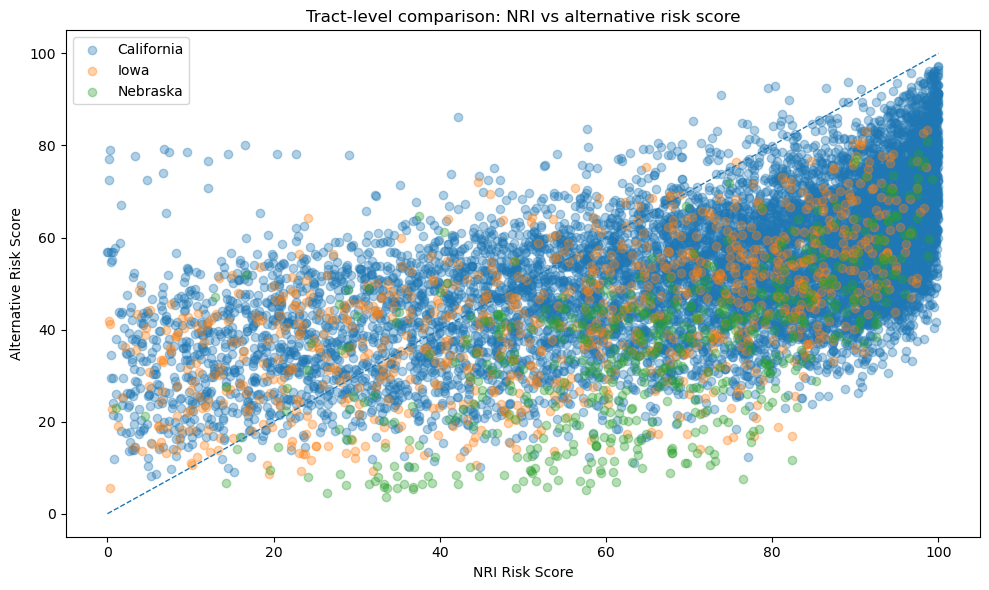

In [180]:
plt.figure(figsize=(10, 6))
for state, temp in merged.groupby("STATE"):
    plt.scatter(temp["RISK_SCORE"], temp["ALT_RISK_SCORE"], alpha=0.35, label=state)

min_lim = min(merged["RISK_SCORE"].min(), merged["ALT_RISK_SCORE"].min())
max_lim = max(merged["RISK_SCORE"].max(), merged["ALT_RISK_SCORE"].max())
plt.plot([min_lim, max_lim], [min_lim, max_lim], linestyle="--", linewidth=1)

plt.xlabel("NRI Risk Score")
plt.ylabel("Alternative Risk Score")
plt.title("Tract-level comparison: NRI vs alternative risk score")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_nri_vs_alt_risk.png", dpi=300)
plt.show()

##  Figure 2: Average tract score by state under each method

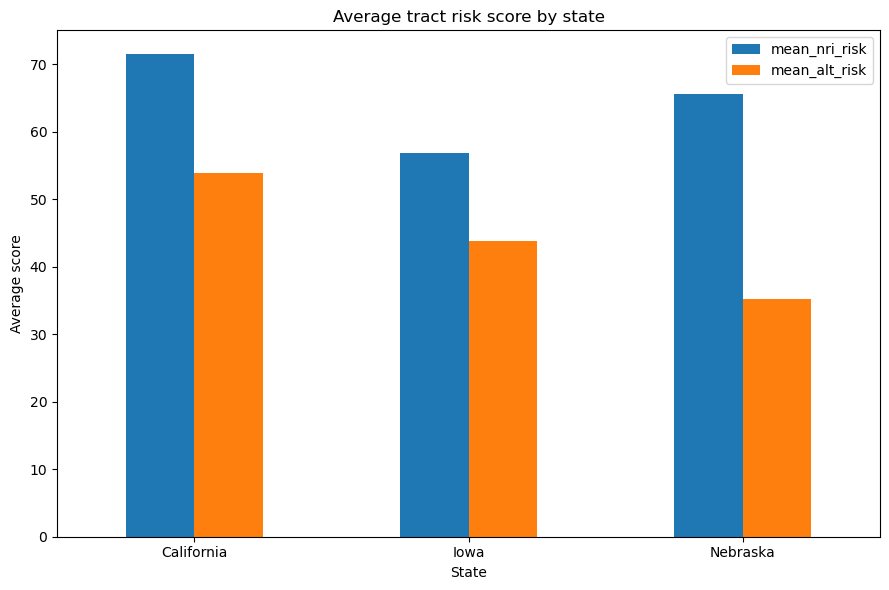

In [182]:
state_plot = state_summary[["mean_nri_risk", "mean_alt_risk"]].copy()

ax = state_plot.plot(kind="bar", figsize=(9, 6))
ax.set_title("Average tract risk score by state")
ax.set_xlabel("State")
ax.set_ylabel("Average score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "bar_state_average_risk_scores.png", dpi=300)
plt.show()

## Identify the tracts with the largest score changes

In [184]:
largest_changes = merged.sort_values("ABS_RISK_SCORE_DIFF", ascending=False)[[
    "STATE", "COUNTY", "TRACTFIPS_STR", "POPULATION",
    "RISK_SCORE", "RISK_RATNG",
    "ALT_RISK_SCORE", "ALT_RISK_RATNG",
    "RISK_SCORE_DIFF", "EAL_PER_CAPITA", "RPL_THEMES", "RESL_SCORE"
]].head(25)

largest_changes.to_csv(TABLE_DIR / "largest_tract_score_changes.csv", index=False)
largest_changes

,STATE,COUNTY,TRACTFIPS_STR,POPULATION,RISK_SCORE,RISK_RATNG,ALT_RISK_SCORE,ALT_RISK_RATNG,RISK_SCORE_DIFF,EAL_PER_CAPITA,RPL_THEMES,RESL_SCORE
8025,California,San Diego,06073009902,3,0.373396,Very Low,79.001812,Relatively High,78.628416,11652.808077,0.4999,5.377325
5307,California,Los Angeles,06037980023,7,0.248534,Very Low,77.073130,Relatively High,76.824596,3295.648996,0.4999,12.692809
5293,California,Los Angeles,06037980009,52,3.364133,Very Low,77.810695,Relatively High,74.446563,7904.112409,0.4999,12.692809
10266,California,Tulare,06107004000,24,6.845992,Very Low,79.229611,Relatively High,72.383619,15337.825230,0.4999,4.199739
9252,California,Santa Barbara,06083980100,3,0.230697,Very Low,72.509036,Relatively High,72.278339,11972.850897,0.4999,48.719346
7880,California,San Diego,06073006200,109,7.463166,Very Low,78.639425,Relatively High,71.176259,4700.680498,0.4999,5.377325
1284,Nebraska,Lancaster,31109010100,7176,82.365742,Relatively Moderate,11.720763,Very Low,-70.644979,272.630322,0.0891,95.559998
6913,California,Riverside,06065980004,6,9.585816,Very Low,78.497977,Relatively High,68.912162,94529.849097,0.4999,9.560479
1082,Nebraska,Douglas,31055007318,9582,76.444846,Relatively Moderate,7.645312,Very Low,-68.799534,197.000441,0.0164,76.370003
9251,California,Santa Barbara,06083980000,15,4.791124,Very Low,72.590040,Relatively High,67.798916,35407.793497,0.4999,48.719346


##  Download or load tract boundaries for mapping


In [186]:
state_fips = {
    "Iowa": "19",
    "Nebraska": "31",
    "California": "06",
}

def load_tract_shapefile(state_name, statefp):
    url = f"https://www2.census.gov/geo/tiger/TIGER2025/TRACT/tl_2025_{statefp}_tract.zip"
    try:
        gdf = gpd.read_file(url)
    except Exception as e:
        raise RuntimeError(
            f"Could not load tract shapefile for {state_name} from {url}. "
            f"Check internet access or download the ZIP manually."
        ) from e
    gdf["STATE"] = state_name
    gdf["TRACTFIPS_STR"] = gdf["GEOID"].astype(str).str.zfill(11)
    return gdf

geo_frames = []
for state_name, statefp in state_fips.items():
    geo_frames.append(load_tract_shapefile(state_name, statefp))

tract_geo = pd.concat(geo_frames, ignore_index=True)
tract_geo = gpd.GeoDataFrame(tract_geo, geometry="geometry", crs=geo_frames[0].crs)
print("Combined tract geometry shape:", tract_geo.shape)
tract_geo[["STATE", "GEOID", "TRACTFIPS_STR"]].head(5)

Combined tract geometry shape: (10578, 16)


,STATE,GEOID,TRACTFIPS_STR
0,Iowa,19049050500,19049050500
1,Iowa,19049050100,19049050100
2,Iowa,19049050600,19049050600
3,Iowa,19049050400,19049050400
4,Iowa,19049050700,19049050700


##  Join the cleaned risk data to the tract geometry

In [188]:
map_df = tract_geo.merge(
    merged,
    on="TRACTFIPS_STR",
    how="left",
    suffixes=("_GEO", "_DATA")
)

map_gdf = gpd.GeoDataFrame(map_df, geometry="geometry", crs=tract_geo.crs)
print("Mapped GeoDataFrame shape:", map_gdf.shape)
map_gdf[["STATE_GEO", "TRACTFIPS_STR", "RISK_SCORE", "ALT_RISK_SCORE"]].head(5)

Mapped GeoDataFrame shape: (10578, 83)


,STATE_GEO,TRACTFIPS_STR,RISK_SCORE,ALT_RISK_SCORE
0,Iowa,19049050500,57.519651,50.604426
1,Iowa,19049050100,68.891584,20.941309
2,Iowa,19049050600,58.380602,27.506086
3,Iowa,19049050400,39.211349,51.014338
4,Iowa,19049050700,77.724662,40.920633


## Alternative risk score by tract

This gives the client a geographic view of how the proposed definition distributes risk across the three states.

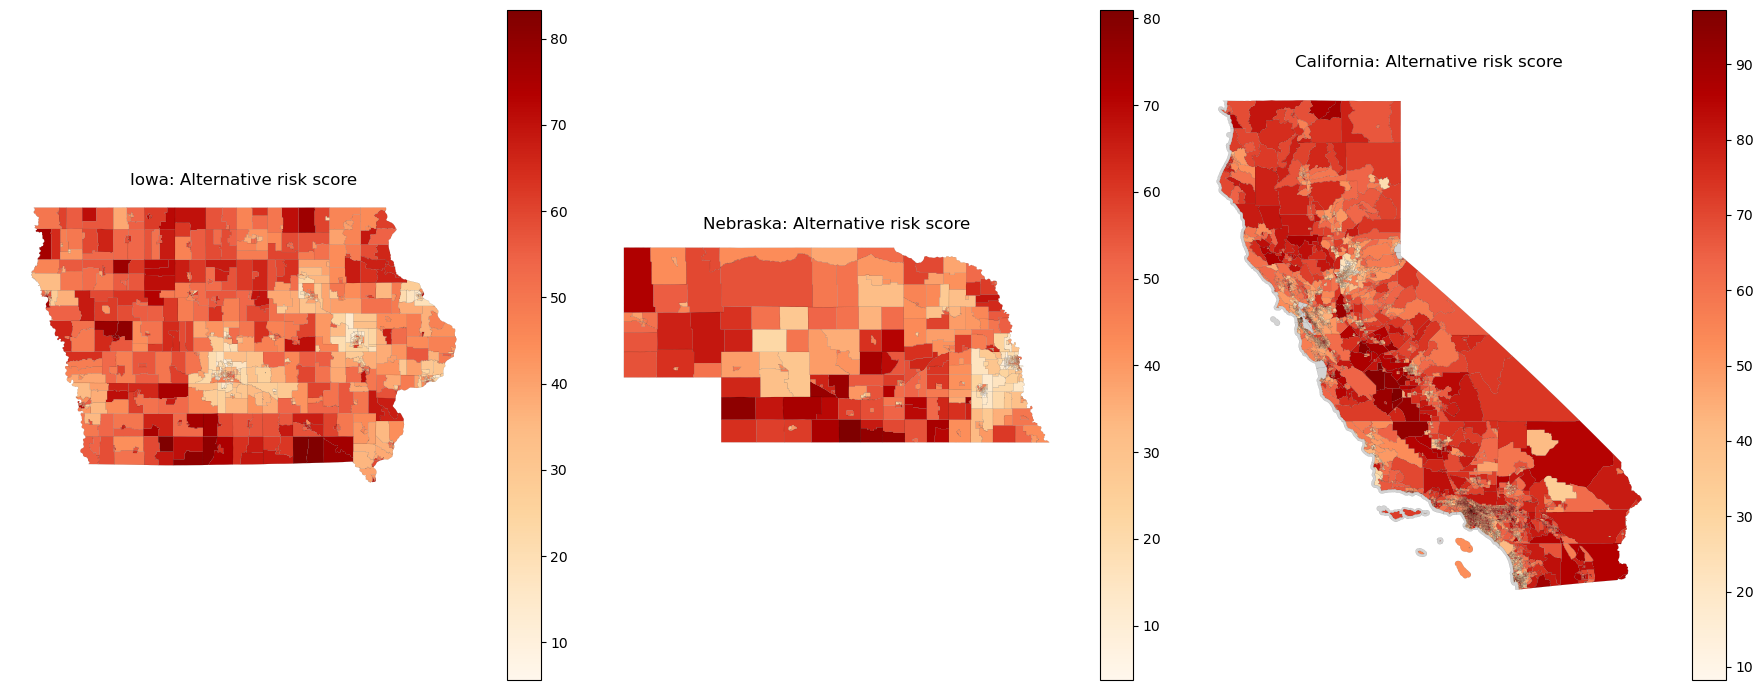

In [190]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, state_name in zip(axes, ["Iowa", "Nebraska", "California"]):
    temp = map_gdf[map_gdf["STATE_GEO"] == state_name]
    temp.plot(
        column="ALT_RISK_SCORE",
        cmap="OrRd",
        linewidth=0.05,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Missing"}
    )
    ax.set_title(f"{state_name}: Alternative risk score")
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "map_alternative_risk_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

## Difference between the alternative and NRI score

Positive values mean the proposed method rates the tract as riskier than FEMA’s NRI score.

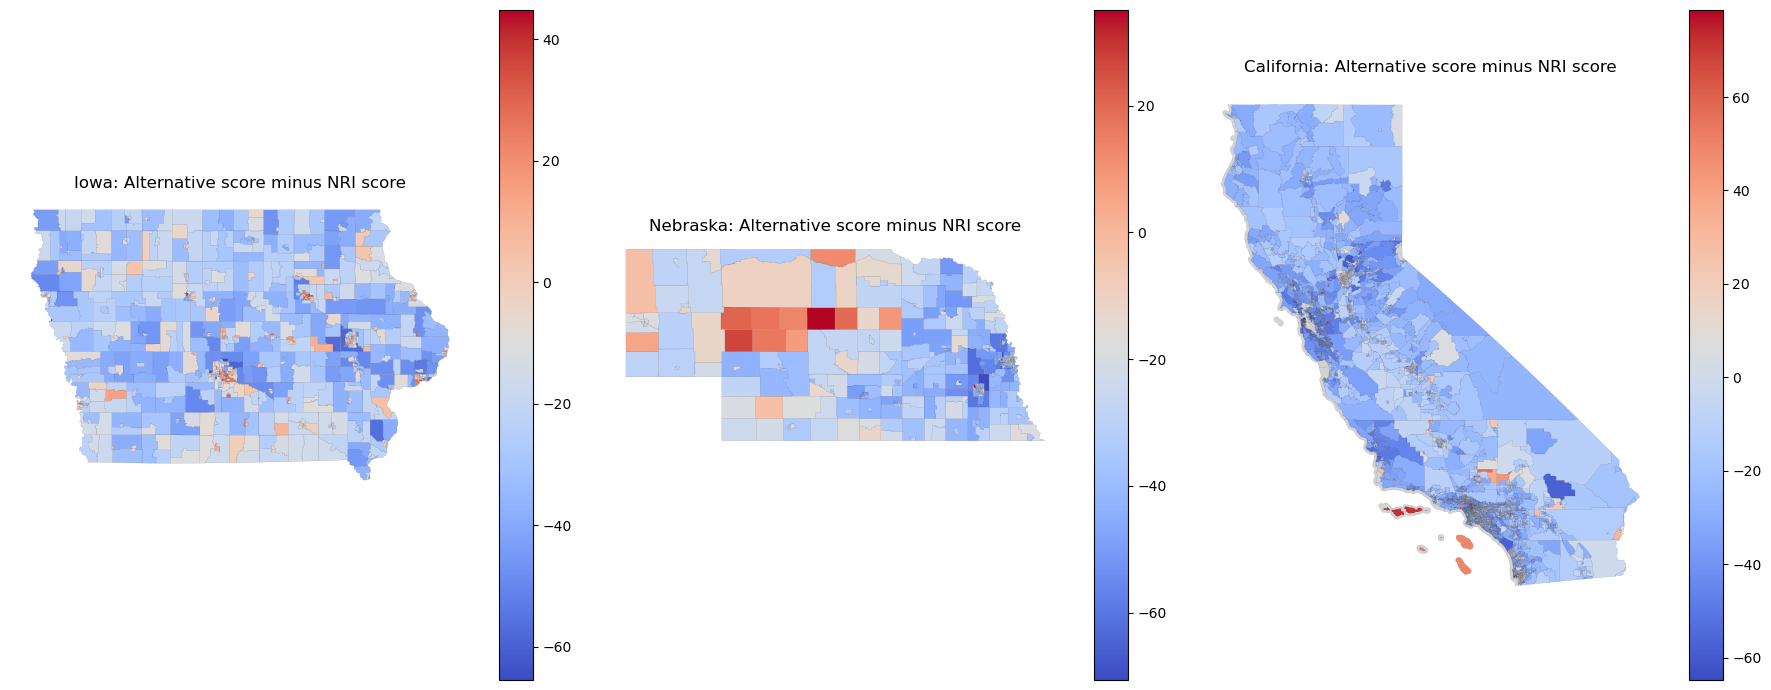

In [192]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, state_name in zip(axes, ["Iowa","Nebraska", "California"]):
    temp = map_gdf[map_gdf["STATE_GEO"] == state_name]
    temp.plot(
        column="RISK_SCORE_DIFF",
        cmap="coolwarm",
        linewidth=0.05,
        edgecolor="black",
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Missing"}
    )
    ax.set_title(f"{state_name}: Alternative score minus NRI score")
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "map_score_difference_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

## NRI vs Alternative Risk Compaarison

In [194]:

tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')


tracts.head()


tracts.crs

tracts.geometry.head()


tracts_clean = tracts.set_crs(epsg = 4326, inplace = True, allow_override = True)


tracts_clean = tracts_clean.to_crs(epsg = 4326)


tracts_clean = tracts_clean.replace(-9999, np.nan)


tracts_clean.crs = "EPSG:3857"

tracts_clean = tracts_clean.to_crs(epsg=4326)



tracts_clean = tracts_clean.to_crs("ESRI:102003")
tracts_clean.head()




print(tracts_clean.columns)
# River Flood custom risk
tracts_clean["RFLD_MY_SCORE"] = (
    tracts_clean["RFLD_EVNTS"] *
    tracts_clean["POPULATION"] *
    tracts_clean["SOVI_SCORE"]
)

# Tornado custom risk
tracts_clean["TRND_MY_SCORE"] = (
    tracts_clean["TRND_EVNTS"] *
    tracts_clean["POPULATION"] *
    tracts_clean["SOVI_SCORE"])
    
# Earthquake custom risk

tracts_clean["ERQK_MY_SCORE"] = (
    tracts_clean["ERQK_EVNTS"] *
    tracts_clean["POPULATION"] *
    tracts_clean["SOVI_SCORE"])
    
def normalize(col):
    return 100 * (col - col.min()) / (col.max() - col.min())

tracts_clean["RFLD_MY_SCORE"] = normalize(tracts_clean["RFLD_MY_SCORE"])
tracts_clean["TRND_MY_SCORE"] = normalize(tracts_clean["TRND_MY_SCORE"])
tracts_clean["ERQK_MY_SCORE"] = normalize(tracts_clean["ERQK_MY_SCORE"])


Index(['NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT', 'TRACTFIPS',
       ...
       'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_N', 'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object', length=469)


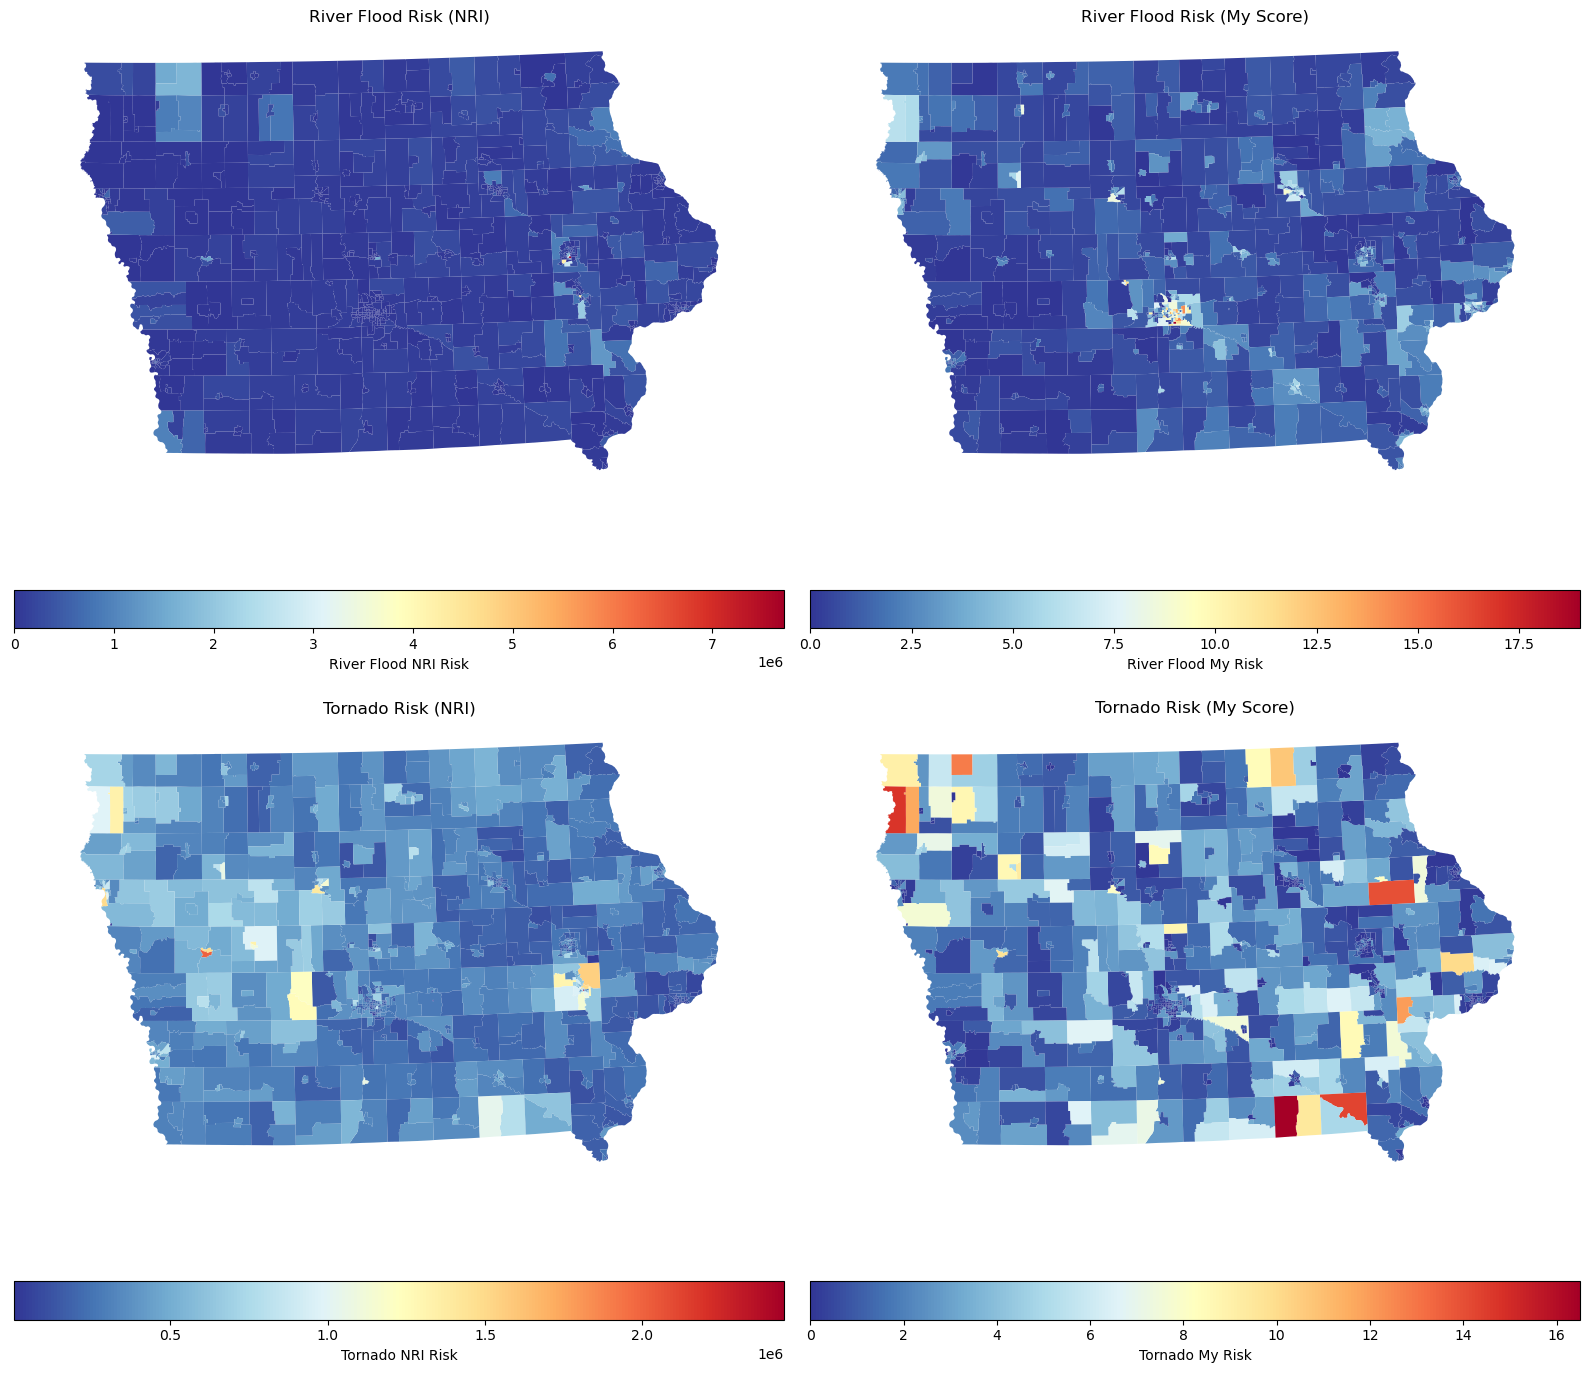

In [195]:
import matplotlib.pyplot as plt

state_name = "Iowa"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# --- 1. River Flood (NRI) ---
state_map.plot(
    column="RFLD_RISKV",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=axes[0,0],
    legend=True,
    legend_kwds={"label": "River Flood NRI Risk", "orientation": "horizontal"},
    missing_kwds={"color": "lightgrey"}
)
axes[0,0].set_title("River Flood Risk (NRI)")

# --- 2. River Flood (Your Score) ---
state_map.plot(
    column="RFLD_MY_SCORE",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=axes[0,1],
    legend=True,
    legend_kwds={"label": "River Flood My Risk", "orientation": "horizontal"},
    missing_kwds={"color": "lightgrey"}
)
axes[0,1].set_title("River Flood Risk (My Score)")

# --- 3. Tornado (NRI) ---
state_map.plot(
    column="TRND_RISKV",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=axes[1,0],
    legend=True,
    legend_kwds={"label": "Tornado NRI Risk", "orientation": "horizontal"},
    missing_kwds={"color": "lightgrey"}
)
axes[1,0].set_title("Tornado Risk (NRI)")

# --- 4. Tornado (Your Score) ---
state_map.plot(
    column="TRND_MY_SCORE",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=axes[1,1],
    legend=True,
    legend_kwds={"label": "Tornado My Risk", "orientation": "horizontal"},
    missing_kwds={"color": "lightgrey"}
)
axes[1,1].set_title("Tornado Risk (My Score)")

# Clean up axes
for ax in axes.flatten():
    ax.set_axis_off()

plt.tight_layout()
plt.show()



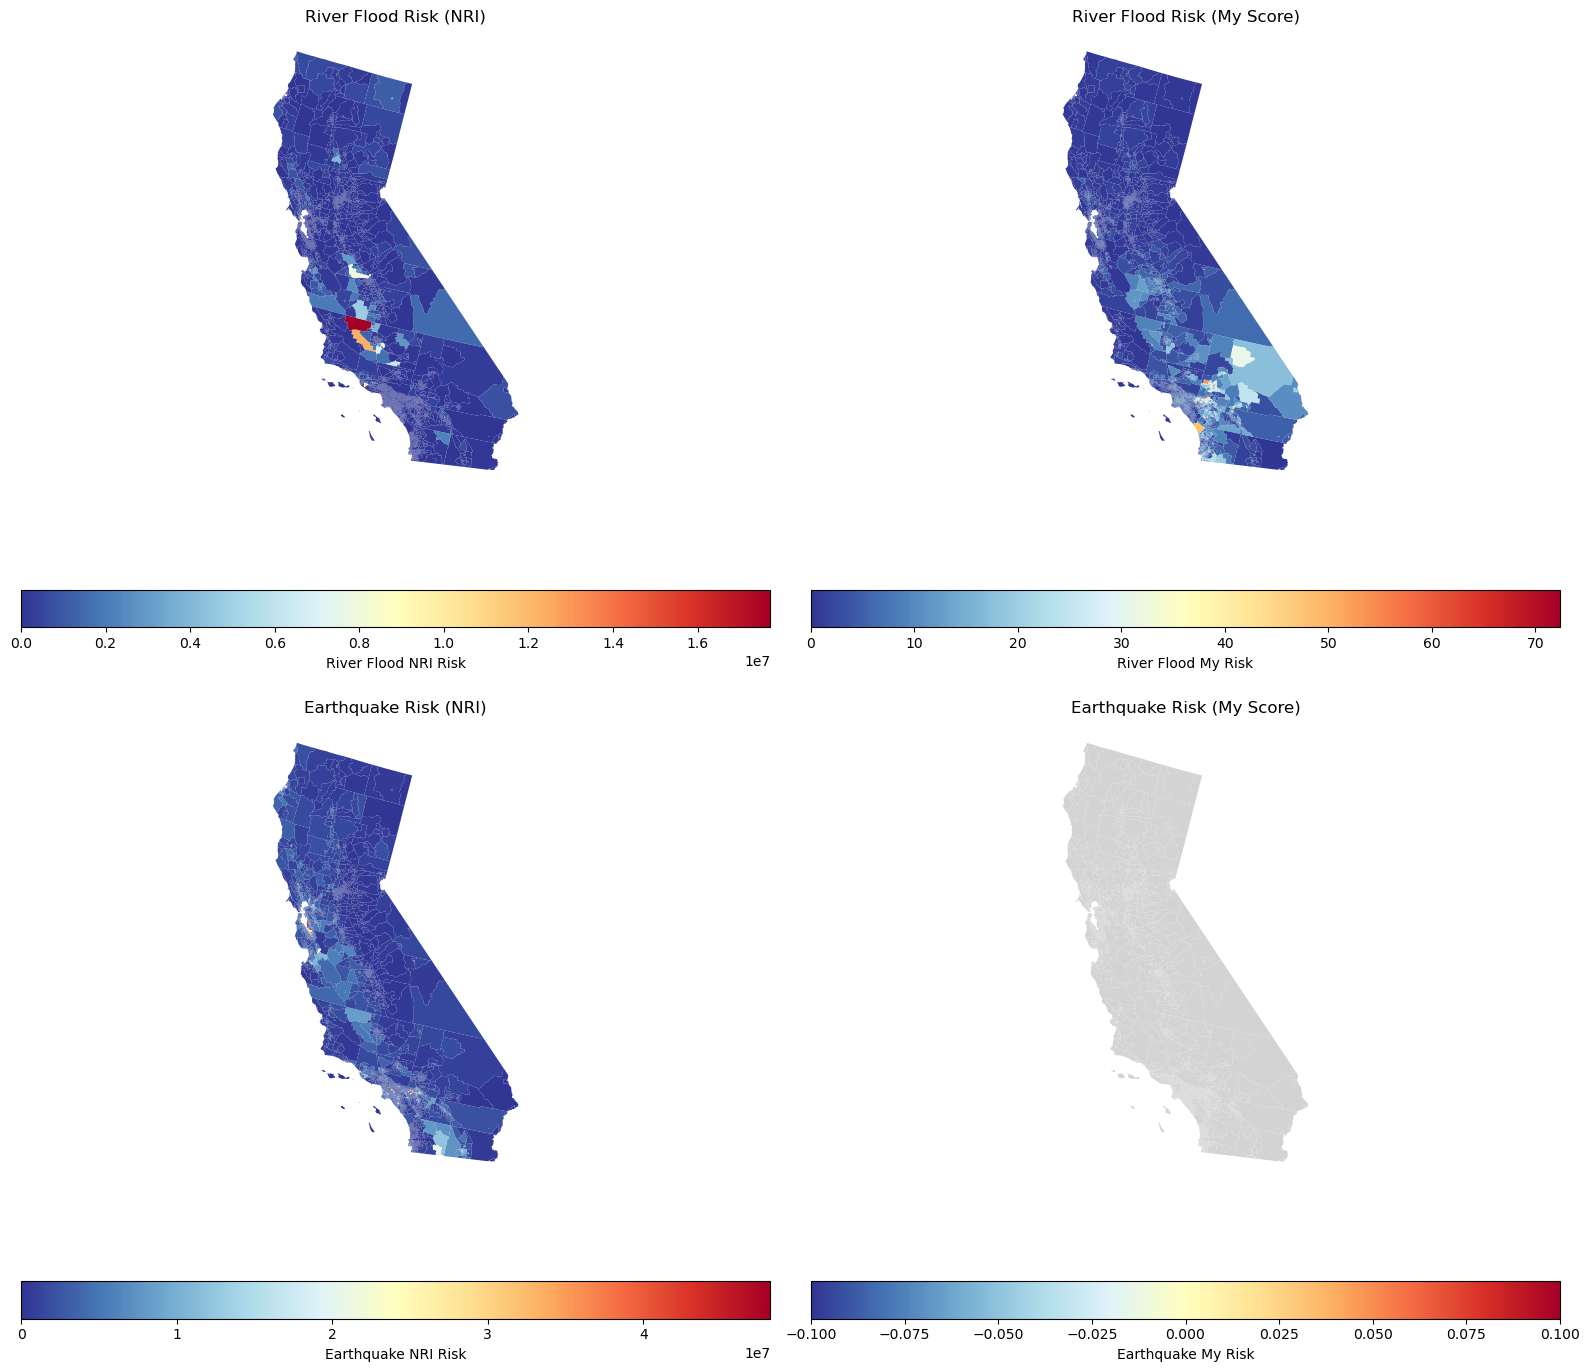

In [150]:
import matplotlib.pyplot as plt

state_name = "California"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# --- 1. River Flood (NRI) ---
state_map.plot(
    column="RFLD_RISKV",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=axes[0,0],
    legend=True,
    legend_kwds={"label": "River Flood NRI Risk", "orientation": "horizontal"},
    missing_kwds={"color": "lightgrey"}
)
axes[0,0].set_title("River Flood Risk (NRI)")

# --- 2. River Flood (Your Score) ---
state_map.plot(
    column="RFLD_MY_SCORE",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=axes[0,1],
    legend=True,
    legend_kwds={"label": "River Flood My Risk", "orientation": "horizontal"},
    missing_kwds={"color": "lightgrey"}
)
axes[0,1].set_title("River Flood Risk (My Score)")

# --- 3. Earthquake (NRI) ---
state_map.plot(
    column="ERQK_RISKV",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=axes[1,0],
    legend=True,
    legend_kwds={"label": "Earthquake NRI Risk", "orientation": "horizontal"},
    missing_kwds={"color": "lightgrey"}
)
axes[1,0].set_title("Earthquake Risk (NRI)")

# --- 4. Earthquake (Your Score) ---
state_map.plot(
    column="ERQK_MY_SCORE",
    cmap="RdYlBu_r",
    linewidth=0,
    ax=axes[1,1],
    legend=True,
    legend_kwds={"label": "Earthquake My Risk", "orientation": "horizontal"},
    missing_kwds={"color": "lightgrey"}
)
axes[1,1].set_title("Earthquake Risk (My Score)")

# Clean up axes
for ax in axes.flatten():
    ax.set_axis_off()

plt.tight_layout()
plt.show()


